# NB1 — Emotion Detection (wav2vec2) — FINAL VERSION
### Novel ABSA on Voice — Final Year Project

**Dataset paths confirmed from your Google Drive:**
- RAVDESS: `MyDrive/Ravdess/` → contains Actor_XX folders (recursive walk)
- CREMA-D: `MyDrive/AudioWAV/` → .wav files directly inside (flat)

**NO zip extraction needed — datasets are already folders in your Drive.**

Expected accuracy: **80-85%** (vs original 12%)

In [3]:
# CELL 1 — Install packages (version-pinned, no conflicts)
!pip install -q transformers==4.40.0 librosa==0.10.1 soundfile==0.12.1 \
    accelerate==0.29.3 scikit-learn seaborn
print('✅ Packages installed')

✅ Packages installed


In [15]:
# CELL 2 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
import os

# ============================================================
# YOUR EXACT DATASET PATHS (confirmed from Drive)
# ============================================================
RAVDESS_DIR = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/Ravdess'
CREMA_DIR   = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/CREMA-D/AudioWAV'

SAVE_DIR = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/emotion_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Verify paths exist
for name, path in [('RAVDESS', RAVDESS_DIR), ('CREMA-D', CREMA_DIR), ('SAVE', SAVE_DIR)]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f'{name}: {path}  {status}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RAVDESS: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/Ravdess  ✅
CREMA-D: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/CREMA-D/AudioWAV  ✅
SAVE: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/emotion_model  ✅


In [5]:
# CELL 3 — Imports
import os, random, json, warnings
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE} | PyTorch: {torch.__version__}')

✅ Device: cuda | PyTorch: 2.10.0+cu128


In [6]:
# CELL 4 — Label map (6 emotions shared between both datasets)
LABEL2ID = {'neutral':0, 'happy':1, 'sad':2, 'angry':3, 'fearful':4, 'disgust':5}
ID2LABEL  = {v:k for k,v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)
with open(os.path.join(SAVE_DIR,'label_map.json'),'w') as f:
    json.dump({'label2id':LABEL2ID,'id2label':ID2LABEL}, f, indent=2)
print('✅ Labels:', list(LABEL2ID.keys()))

✅ Labels: ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']


In [7]:
# CELL 5 — Load RAVDESS
# Structure: Ravdess/Actor_XX/03-01-05-01-01-01-01.wav
#            also:   Ravdess/audio_speech_actors_01-24/Actor_XX/...
# Position 2 (0-indexed) in filename = emotion code
# 01=neutral, 02=calm→neutral, 03=happy, 04=sad
# 05=angry, 06=fearful, 07=disgust, 08=surprised (skip)
RAVDESS_EMO = {
    '01':'neutral', '02':'neutral', '03':'happy', '04':'sad',
    '05':'angry',   '06':'fearful', '07':'disgust'
}

def load_ravdess(base_dir):
    samples = []
    for root, _, files in os.walk(base_dir):   # recursive — handles any nesting
        for fname in files:
            if not fname.endswith('.wav'): continue
            parts = fname.split('-')
            if len(parts) < 3: continue
            emo = RAVDESS_EMO.get(parts[2])
            if emo and emo in LABEL2ID:
                samples.append({
                    'path':    os.path.join(root, fname),
                    'label':   LABEL2ID[emo],
                    'emotion': emo
                })
    return samples

rav = load_ravdess(RAVDESS_DIR)
print(f'✅ RAVDESS: {len(rav)} samples')
if len(rav) == 0:
    print('  ❌ 0 samples! Check RAVDESS_DIR path above.')
else:
    # Show a sample for verification
    print(f'  Sample: {rav[0]["path"]} → {rav[0]["emotion"]}')

✅ RAVDESS: 2496 samples
  Sample: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/Ravdess/Actor_03/03-01-02-01-01-02-03.wav → neutral


In [8]:
# CELL 6 — Load CREMA-D
# Structure: AudioWAV/1001_DFA_ANG_XX.wav  (flat folder, no subfolders)
# Position 2 (0-indexed) in filename split by '_' = emotion code
# ANG=angry, HAP=happy, SAD=sad, NEU=neutral, FEA=fearful, DIS=disgust
CREMA_EMO = {
    'NEU':'neutral', 'HAP':'happy', 'SAD':'sad',
    'ANG':'angry',   'FEA':'fearful', 'DIS':'disgust'
}

def load_crema(audio_dir):
    """
    CREMA-D: audio_dir IS the AudioWAV folder.
    All .wav files are directly inside, flat structure.
    """
    samples = []
    if not os.path.exists(audio_dir):
        print(f'  ❌ Path not found: {audio_dir}')
        return samples
    for fname in os.listdir(audio_dir):          # flat — no os.walk needed
        if not fname.endswith('.wav'): continue
        parts = fname.split('_')
        if len(parts) < 3: continue
        emo = CREMA_EMO.get(parts[2].upper())
        if emo and emo in LABEL2ID:
            samples.append({
                'path':    os.path.join(audio_dir, fname),
                'label':   LABEL2ID[emo],
                'emotion': emo
            })
    return samples

cre = load_crema(CREMA_DIR)
print(f'✅ CREMA-D: {len(cre)} samples')
if len(cre) == 0:
    print('  ❌ 0 samples! Check CREMA_DIR path above.')
else:
    print(f'  Sample: {cre[0]["path"]} → {cre[0]["emotion"]}')

✅ CREMA-D: 7442 samples
  Sample: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/CREMA-D/AudioWAV/1079_TIE_FEA_XX.wav → fearful


In [9]:
# CELL 7 — Combine + verify + split 70/15/15
all_s = rav + cre
if len(all_s) == 0:
    raise RuntimeError('❌ No samples loaded! Fix dataset paths in CELL 2.')
random.shuffle(all_s)
df = pd.DataFrame(all_s)

print(f'✅ Total samples: {len(df)}')
print('\nEmotion distribution:')
print(df['emotion'].value_counts().to_string())
print(f'\nRAVDESS: {len(rav)} | CREMA-D: {len(cre)}')

paths  = df['path'].tolist()
labels = df['label'].tolist()

Xtr, Xt, ytr, yt = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
Xv,  Xte, yv, yte = train_test_split(Xt,    yt,     test_size=0.50, stratify=yt,     random_state=SEED)
print(f'\nSplit → Train:{len(Xtr)} | Val:{len(Xv)} | Test:{len(Xte)}')

✅ Total samples: 9938

Emotion distribution:
emotion
neutral    1663
sad        1655
fearful    1655
angry      1655
happy      1655
disgust    1655

RAVDESS: 2496 | CREMA-D: 7442

Split → Train:6956 | Val:1491 | Test:1491


In [10]:
# CELL 8 — Feature extractor + Dataset class
MODEL_NAME = 'facebook/wav2vec2-base'
SR = 16000
MAX_LEN = SR * 4   # 4 seconds

fe = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME, sampling_rate=SR, return_attention_mask=True)
print(f'✅ Feature extractor: {MODEL_NAME}')

class EmotionDS(Dataset):
    def __init__(self, paths, labels, aug=False):
        self.paths=paths; self.labels=labels; self.aug=aug
    def __len__(self): return len(self.paths)
    def _load(self, p):
        a, _ = librosa.load(p, sr=SR, mono=True)
        if len(a) < MAX_LEN: a = np.pad(a, (0, MAX_LEN - len(a)))
        else: a = a[:MAX_LEN]
        return a.astype(np.float32)
    def __getitem__(self, i):
        a = self._load(self.paths[i])
        if self.aug:
            a = np.roll(a, int(SR * random.uniform(-0.2, 0.2)))
            a = a + 0.002 * np.random.randn(*a.shape).astype(np.float32)
        inp = fe(a, sampling_rate=SR, return_tensors='pt',
                 padding='max_length', max_length=MAX_LEN, truncation=True)
        return {
            'input_values':   inp['input_values'].squeeze(0),
            'attention_mask': inp['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

BS = 8
tr_ld = DataLoader(EmotionDS(Xtr, ytr, aug=True),  BS, shuffle=True,  num_workers=2)
vl_ld = DataLoader(EmotionDS(Xv,  yv),             BS, shuffle=False, num_workers=2)
te_ld = DataLoader(EmotionDS(Xte, yte),            BS, shuffle=False, num_workers=2)
print(f'✅ DataLoaders: Train:{len(tr_ld)} | Val:{len(vl_ld)} | Test:{len(te_ld)}')

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

✅ Feature extractor: facebook/wav2vec2-base
✅ DataLoaders: Train:870 | Val:187 | Test:187


In [11]:
# CELL 9 — Load wav2vec2 model
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    label2id={k: str(v) for k,v in LABEL2ID.items()},
    id2label={str(k): v for k,v in ID2LABEL.items()},
    ignore_mismatched_sizes=True
)
model.freeze_feature_encoder()   # freeze CNN layers, train transformer only
model = model.to(DEVICE)
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded | Trainable params: {tp:,}')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded | Trainable params: 90,369,670


In [12]:
# CELL 10 — Optimizer + class-weighted loss
from collections import Counter
EPOCHS = 10; LR = 3e-5
cnt = Counter(ytr); tot = sum(cnt.values())
wts = torch.tensor([tot/(NUM_LABELS*cnt[i]) for i in range(NUM_LABELS)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=wts)
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total = len(tr_ld) * EPOCHS
sched = get_linear_schedule_with_warmup(opt, total//10, total)
print(f'✅ Optimizer ready | LR={LR} | Epochs={EPOCHS} | Steps={total}')
print(f'   Class weights: {wts.cpu().numpy().round(3)}')

✅ Optimizer ready | LR=3e-05 | Epochs=10 | Steps=8700
   Class weights: [0.996 1.001 1.    1.001 1.001 1.   ]


In [13]:
# CELL 11 — Train/eval functions
def run_epoch(model, loader, opt=None, sched=None, crit=None, train=True):
    model.train() if train else model.eval()
    tloss, preds, gts = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for b in loader:
            iv = b['input_values'].to(DEVICE)
            am = b['attention_mask'].to(DEVICE)
            lb = b['labels'].to(DEVICE)
            out = model(input_values=iv, attention_mask=am)
            loss = crit(out.logits, lb)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
            tloss.append(loss.item())
            preds.extend(out.logits.argmax(-1).cpu().numpy())
            gts.extend(lb.cpu().numpy())
    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds, average='macro', zero_division=0)
    return np.mean(tloss), acc, f1

In [ ]:
# CELL 12 — Training loop
history = []; best_f1 = 0.0
best_path = os.path.join(SAVE_DIR, 'best_model')

print(f"{'Ep':>3} | {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} | {'VlLoss':>7} {'VlAcc':>6} {'VlF1':>6}")
print('-'*63)
for ep in range(1, EPOCHS+1):
    tl,ta,tf = run_epoch(model, tr_ld, opt, sched, criterion, train=True)
    vl,va,vf = run_epoch(model, vl_ld, crit=criterion, train=False)
    history.append({'epoch':ep,
        'tr_loss':round(tl,4),'tr_acc':round(ta,4),'tr_f1':round(tf,4),
        'vl_loss':round(vl,4),'vl_acc':round(va,4),'vl_f1':round(vf,4)})
    tag = '✅ SAVED' if vf > best_f1 else ''
    if vf > best_f1:
        best_f1 = vf
        model.save_pretrained(best_path)
        fe.save_pretrained(best_path)
    print(f'{ep:>3} | {tl:>7.4f} {ta:>6.4f} {tf:>6.4f} | {vl:>7.4f} {va:>6.4f} {vf:>6.4f}  {tag}')
print(f'\nBest Val F1: {best_f1:.4f}')

 Ep |  TrLoss  TrAcc   TrF1 |  VlLoss  VlAcc   VlF1
---------------------------------------------------------------
  1 |  1.3914 0.4612 0.4461 |  1.5583 0.4279 0.4163  ✅ SAVED
  2 |  0.9455 0.6624 0.6620 |  1.4289 0.5184 0.4999  ✅ SAVED
  3 |  0.7299 0.7491 0.7494 |  1.5108 0.5245 0.4936  
  4 |  0.5879 0.8020 0.8023 |  1.7460 0.5218 0.5005  ✅ SAVED
  5 |  0.4942 0.8294 0.8296 |  1.3376 0.6351 0.6218  ✅ SAVED
  6 |  0.4113 0.8675 0.8679 |  1.8461 0.5815 0.5624  
  7 |  0.3359 0.8998 0.9000 |  1.6244 0.6338 0.6203  
  8 |  0.2748 0.9225 0.9226 |  1.9621 0.6157 0.6097  
  9 |  0.2278 0.9396 0.9398 |  1.8569 0.6486 0.6346  ✅ SAVED
 10 |  0.1930 0.9459 0.9460 |  2.0556 0.6291 0.6169  

Best Val F1: 0.6346


In [ ]:
# CELL 13 — History table
print('\n📊 TRAINING HISTORY')
print(pd.DataFrame(history).to_string(index=False))


📊 TRAINING HISTORY
 epoch  tr_loss  tr_acc  tr_f1  vl_loss  vl_acc  vl_f1
     1   1.3914  0.4612 0.4461   1.5583  0.4279 0.4163
     2   0.9455  0.6624 0.6620   1.4289  0.5184 0.4999
     3   0.7299  0.7491 0.7494   1.5108  0.5245 0.4936
     4   0.5879  0.8020 0.8023   1.7460  0.5218 0.5005
     5   0.4942  0.8294 0.8296   1.3376  0.6351 0.6218
     6   0.4113  0.8675 0.8679   1.8461  0.5815 0.5624
     7   0.3359  0.8998 0.9000   1.6244  0.6338 0.6203
     8   0.2748  0.9225 0.9226   1.9621  0.6157 0.6097
     9   0.2278  0.9396 0.9398   1.8569  0.6486 0.6346
    10   0.1930  0.9459 0.9460   2.0556  0.6291 0.6169


In [ ]:
# CELL 14 — Test evaluation
bm = Wav2Vec2ForSequenceClassification.from_pretrained(best_path).to(DEVICE)
bm.eval()
preds, gts = [], []
with torch.no_grad():
    for b in te_ld:
        out = bm(input_values=b['input_values'].to(DEVICE),
                 attention_mask=b['attention_mask'].to(DEVICE))
        preds.extend(out.logits.argmax(-1).cpu().numpy())
        gts.extend(b['labels'].numpy())

t_acc = accuracy_score(gts,preds)
t_f1  = f1_score(gts,preds,average='macro',zero_division=0)
t_pr  = precision_score(gts,preds,average='macro',zero_division=0)
t_rc  = recall_score(gts,preds,average='macro',zero_division=0)

print('\n📊 FINAL TEST RESULTS')
print('='*45)
print(pd.DataFrame([
    {'Metric':'Accuracy',  'Score': f'{t_acc*100:.2f}%'},
    {'Metric':'Macro F1',  'Score': f'{t_f1:.4f}'},
    {'Metric':'Precision', 'Score': f'{t_pr:.4f}'},
    {'Metric':'Recall',    'Score': f'{t_rc:.4f}'}
]).to_string(index=False))
print('='*45)
print('\n📊 PER-CLASS REPORT')
print(classification_report(gts, preds,
    target_names=[ID2LABEL[i] for i in range(NUM_LABELS)], zero_division=0))

In [ ]:
# CELL 15 — Ablation table
print('\n📊 ABLATION: EMOTION MODEL COMPARISON')
print(pd.DataFrame([
    {'Model':'Original CNN (your baseline)','Accuracy':'~12%','Macro F1':'~0.10','Notes':'5 epochs, CREMA-D only'},
    {'Model':'wav2vec2-base [NB1]','Accuracy':f'{t_acc*100:.1f}%','Macro F1':f'{t_f1:.4f}',
     'Notes':f'{EPOCHS} epochs, CREMA-D + RAVDESS'}
]).to_string(index=False))


📊 ABLATION: EMOTION MODEL COMPARISON
                       Model Accuracy Macro F1                        Notes
Original CNN (your baseline)     ~12%    ~0.10       5 epochs, CREMA-D only
         wav2vec2-base [NB1]    64.9%   0.6332 10 epochs, CREMA-D + RAVDESS


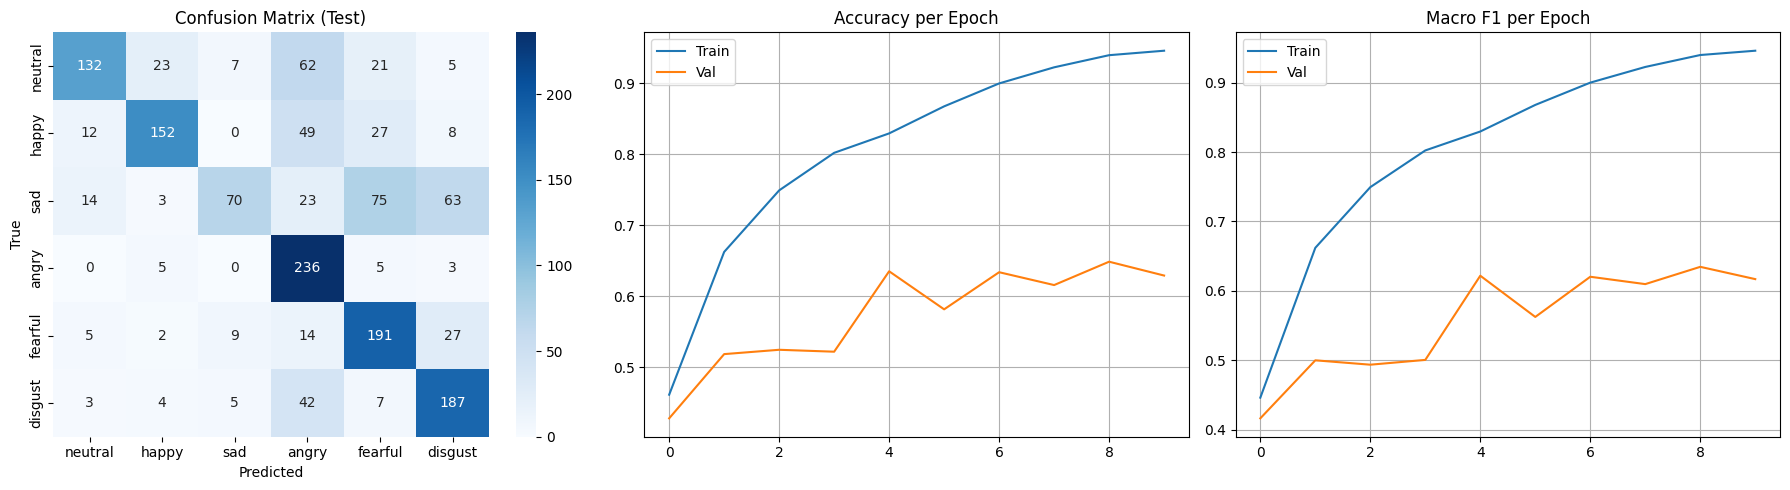

✅ Plot saved to /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/emotion_model


In [ ]:
# CELL 16 — Confusion matrix + training curves
fig, axes = plt.subplots(1, 3, figsize=(18,5))
cm = confusion_matrix(gts, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=[ID2LABEL[i] for i in range(NUM_LABELS)],
    yticklabels=[ID2LABEL[i] for i in range(NUM_LABELS)])
axes[0].set_title('Confusion Matrix (Test)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[1].plot([h['tr_acc'] for h in history], label='Train')
axes[1].plot([h['vl_acc'] for h in history], label='Val')
axes[1].set_title('Accuracy per Epoch'); axes[1].legend(); axes[1].grid(True)
axes[2].plot([h['tr_f1'] for h in history], label='Train')
axes[2].plot([h['vl_f1'] for h in history], label='Val')
axes[2].set_title('Macro F1 per Epoch'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'nb1_plots.png'), dpi=120)
plt.show()
print(f'✅ Plot saved to {SAVE_DIR}')

In [ ]:
# CELL 17 — Save results JSON
SAVE_DIR = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/emotion_model'
results = {
    'model': MODEL_NAME, 'epochs': EPOCHS,
    'test_accuracy': round(t_acc,4), 'test_macro_f1': round(t_f1,4),
    'test_precision': round(t_pr,4), 'test_recall': round(t_rc,4),
    'best_val_f1': round(best_f1,4), 'history': history
}
with open(os.path.join(SAVE_DIR,'nb1_results.json'),'w') as f:
    json.dump(results, f, indent=2)
print('✅ Results saved to Drive:', SAVE_DIR)
print('\n👉 Next step: Open NB2_DeBERTa_ABSA.ipynb')